In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch_geometric

# from graphMatching import *
from matplotlib.patches import ConnectionPatch
from model_tg import *
from networkx import read_edgelist
from scipy.io import loadmat
from utils import *

/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  import torch_geometric.typing
/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  import torch_geometric.typing
/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: /home/ealva

In [2]:
print(torch_geometric.__version__)

2.7.0


In [3]:
# !pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.1.0+cu121.html
# !pip install torch-geometric

In [4]:
data = "mentos" # args.dataset

device = torch.device('cuda:0' if torch.cuda.is_available() else "cpu")
train_features = {}
if (data == "ACM_DBLP"):
	train_set = ["ACM", "DBLP"]
	input_dim = 17
	b = np.load('data/ACM-DBLP.npz')
	train_features["ACM"] = [torch.from_numpy(b["x1"]).float()]
	train_features["DBLP"] = [torch.from_numpy(b["x2"]).float()]
	test_pairs = b['test_pairs'].astype(np.int32)
	NUM_HIDDEN_LAYERS = 12
	HIDDEN_DIM = [1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024]
	output_feature_size = 1024
	lr = 0.0001
	epoch = 100
elif (data == "Douban Online_Offline"):
	a1, f1, a2, f2, test_pairs = load_douban()
	f1 = f1.A
	f2 = f2.A
	train_set = ["Online", "Offline"]
	input_dim = 538
	test_pairs = torch.tensor(np.array(test_pairs, dtype=int)) - 1
	test_pairs = test_pairs.numpy()
	train_features["Online"] = [torch.from_numpy(f1).float()]
	train_features["Offline"] = [torch.from_numpy(f2).float()]
	NUM_HIDDEN_LAYERS = 6
	HIDDEN_DIM = [512,512,512,512,512,512,512]
	output_feature_size = 512
	lr = 0.0001
	epoch = 100
elif (data == "mentos"):
	train_set = [
		"Orange_1", "Orange_2",
		"Red_1", "Red_2",
		"Yellow_1", "Yellow_2",
	]
	input_dim = 3

	NUM_HIDDEN_LAYERS = 12
	HIDDEN_DIM = [1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024]
	output_feature_size = 1024
	lr = 0.0001
	epoch = 100


In [ ]:
b["pos_pairs"]

In [ ]:
print(train_features["ACM"][0].shape)
train_features["ACM"]

In [ ]:
train_features

In [ ]:
train_features["ACM"][0]

In [ ]:
train_features[train_set[0]][0]

In [ ]:
train_features["DBLP"][0]

In [ ]:
train_features[train_set[1]][0]

In [ ]:
""" temp = torch.from_numpy(b["x1"]).float() # G1, features
print(temp.shape)
temp """

In [ ]:
""" temp = torch.from_numpy(b["x2"]).float() # G2, features
print(temp.shape)
temp """

In [ ]:
""" temp = b["test_pairs"]
print(temp.shape)
temp """

In [ ]:
test_pairs

In [ ]:
train_set

In [5]:
print("Loading training datasets")

train_loader = {}
train_features = {}
train_weights = {}
if data == "mentos":
	train_features_aux = {}
	for dataset in train_set:
		df_nodes = pd.read_csv("graphs_data/{}/nodes_{}.csv".format(data, dataset))
		train_features_aux[dataset] = df_nodes.iloc[:, 2:-1].values
		# idx,id,mz,rt,intensity_mean,intensity_cv

	train_loader_aux = {}
	train_weight_aux = {}
	for dataset in train_set:
		df_edges_data = pd.read_csv("graphs_data/{}/edges_{}.csv".format(data, dataset))
		train_loader_aux[dataset] = df_edges_data.iloc[:, [0, 1]].values
		train_weight_aux[dataset] = df_edges_data.iloc[:, 2].values

	# Construct adjacency matrices
	for dataset, features in train_features_aux.items():
		train_features[dataset] = [torch.from_numpy(features).float()]
	
	for dataset, weights in train_weight_aux.items():
		train_weights[dataset] = [torch.from_numpy(weights).float()]

	# train_loader = {}
	for dataset, loader in train_loader_aux.items():
		n = train_features[dataset][0].shape[0]
		matrix = torch.zeros(n, n)

		for item in loader:
			matrix[item[0]][item[1]] = 1
			matrix[item[1]][item[0]] = 1
		train_loader[dataset] = [matrix]
else:
	for dataset in train_set:
		train_loader[dataset] = [load_adj(dataset)]


Loading training datasets


In [ ]:
train_loader.keys()

In [ ]:
train_loader

---

In [ ]:
adj_tensor = train_loader["ACM"][0]
print(adj_tensor.shape)
adj_tensor

In [ ]:
adj = coo_matrix(adj_tensor.numpy())
print(adj.shape)
adj

In [ ]:
adj_norm = preprocess_graph(adj)
print(len(adj_norm))
adj_norm

In [ ]:
adj_norm[0]

In [ ]:
adj_norm[1]

In [ ]:
adj_norm[2]

In [ ]:
adj_norm = torch.sparse.FloatTensor(torch.LongTensor(adj_norm[0].T),
									torch.FloatTensor(adj_norm[1]),
									torch.Size(adj_norm[2])).to(device)
print(adj_norm.shape)
adj_norm

In [ ]:
type(adj_norm)

In [ ]:
adj_norm

In [ ]:
# Transform data

adj_coo = adj_norm.coalesce()  # Asegurar formato COO
edge_index = adj_coo.indices() # [2, E]
edge_weight = adj_coo.values().view(-1, 1) # Fron [E] to [E,1]
edge_attr = torch.cat([
	edge_weight.abs(),         # strength
	torch.sign(edge_weight),   # direction (+1, -1)
	edge_weight ** 2           # nonlinearity
], dim=1)            # [E,3]

features = train_features["ACM"][0]
print(edge_index.shape)
print(edge_index)

print(edge_weight.shape)
print(edge_weight)

print(edge_attr.shape)
print(edge_attr)

print(features.shape)
print(features)

In [ ]:
# Remove this
"""
# reduce dimensions of node features
for item in train_features:
	feat = train_features[item][0]
	reduced_feat = feat[:, :3]  # Reduce to first 'input_dim' dimensions
	train_features[item][0] = reduced_feat
train_features """

In [ ]:
# Remove this
# PCA

"""
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

for item in train_features:
	feat = train_features[item][0]

	scaler = StandardScaler()
	X_scaled = scaler.fit_transform(feat)

	pca = PCA(n_components=3)
	X_pca = pca.fit_transform(X_scaled)

	train_features[item][0] = torch.from_numpy(X_pca).float()
train_features """

In [ ]:
train_features

In [ ]:
# Remove this
# Scaler

""" from sklearn.preprocessing import StandardScaler

for item in train_features:
	feat = train_features[item][0]

	scaler = StandardScaler()
	X_scaled = scaler.fit_transform(feat)

	train_features[item][0] = torch.from_numpy(X_scaled).float()
train_features """

---

In [ ]:
""" temp = train_loader["ACM"][0]
print(temp.shape)
temp """

In [ ]:
""" temp = train_loader["DBLP"][0]
print(temp.shape)
temp """

In [6]:
train_set

['Orange_1', 'Orange_2', 'Red_1', 'Red_2', 'Yellow_1', 'Yellow_2']

In [7]:
train_loader

{'Orange_1': [tensor([[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 0., 1., 1.],
          [1., 1., 0.,  ..., 0., 0., 1.],
          ...,
          [0., 0., 0.,  ..., 0., 1., 1.],
          [0., 1., 0.,  ..., 1., 0., 1.],
          [0., 1., 1.,  ..., 1., 1., 0.]])],
 'Orange_2': [tensor([[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 0.,  ..., 1., 1., 1.],
          [1., 0., 0.,  ..., 1., 1., 0.],
          ...,
          [0., 1., 1.,  ..., 0., 1., 1.],
          [0., 1., 1.,  ..., 1., 0., 1.],
          [0., 1., 0.,  ..., 1., 1., 0.]])],
 'Red_1': [tensor([[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 0.,  ..., 1., 1., 1.],
          [1., 0., 0.,  ..., 1., 0., 0.],
          ...,
          [0., 1., 1.,  ..., 0., 1., 1.],
          [0., 1., 0.,  ..., 1., 0., 1.],
          [0., 1., 0.,  ..., 1., 1., 0.]])],
 'Red_2': [tensor([[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 0., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.],
          ...,
       

In [8]:
train_features

{'Orange_1': [tensor([[353.9457,   0.7670,  -4.7029],
          [ 58.0235,   1.0550,   4.6962],
          [ 73.0206,   1.1380,   4.7499],
          ...,
          [105.0998,  33.6660,   4.9806],
          [ 93.0947,  33.6730,   5.0040],
          [228.1539,  33.7010,   4.0138]])],
 'Orange_2': [tensor([[353.9457,   0.7670,  -3.4114],
          [109.1039,   0.9920,   4.7156],
          [ 58.0235,   1.0550,   4.8256],
          ...,
          [109.1250,  33.5440,   5.1210],
          [109.1162,  33.6030,   5.1531],
          [ 93.0947,  33.6730,   5.2474]])],
 'Red_1': [tensor([[ 77.1277,   0.8490,   5.1084],
          [109.1039,   0.9920,   3.2162],
          [ 58.0235,   1.0550,   4.2597],
          ...,
          [ 83.0990,  33.6310,   4.4899],
          [105.0998,  33.6660,   4.6991],
          [228.1539,  33.7010,   3.5178]])],
 'Red_2': [tensor([[ 77.1277,   0.8490,   4.8881],
          [ 45.9701,   0.8620,   5.2904],
          [109.1039,   0.9920,   4.4780],
          ...,
       

In [9]:
train_weights

{'Orange_1': [tensor([ 0.6754,  0.9323, -0.9958,  ..., -0.8672, -0.6263, -0.9313])],
 'Orange_2': [tensor([ 0.5688,  0.7638, -0.5769,  ..., -0.9907,  0.7841,  0.8612])],
 'Red_1': [tensor([ 0.5332, -0.9682, -0.6354,  ..., -0.7341, -0.6105, -0.9860])],
 'Red_2': [tensor([ 0.8170, -0.7395,  0.6687,  ...,  0.9946,  0.9995, -0.9973])],
 'Yellow_1': [tensor([ 0.7178, -0.7398, -0.9836,  ..., -0.9971, -1.0000, -0.9966])],
 'Yellow_2': [tensor([ 0.5940,  0.7384, -0.5071,  ...,  1.0000, -0.9974,  0.9979])]}

In [11]:
# Init

encoder = "GIN" # Change GIN, GINE
epoch = 20 # remove
output_feature_size = 3 # remove
flag = True # remove

if encoder == "GIN":
	input_dim = 3
	GAE = TGAE_GIN(NUM_HIDDEN_LAYERS,
				input_dim,
				HIDDEN_DIM,
				output_feature_size).to(device)
elif encoder == "GINE":
	input_dim = 17 # Change 3

	""" for item in train_features:
		feat = train_features[item][0]
		reduced_feat = feat[:, :3]  # Reduce to first 'input_dim' dimensions
		train_features[item][0] = reduced_feat """

	GAE = TGAE_GINE(NUM_HIDDEN_LAYERS,
			input_dim,
			HIDDEN_DIM,
			output_feature_size).to(device)

In [12]:
print("Generating training features")
print("Fitting model", encoder)
# fit_TGAE_subgraph(data, len(train_set) * (1 + 1), model, epoch, train_loader, train_features, device, lr,test_pairs)

# ---
no_samples = len(train_set) * (1 + 1)
# GAE = model
# ---

best_hitAtOne = 0
best_hitAtFive = 0
best_hitAtTen = 0
best_hitAtFifty = 0

optimizer = Adam(GAE.parameters(), lr=lr,weight_decay=5e-4)

loop_obj = tqdm(range(1, epoch + 1))
for step in loop_obj:
	loop_obj.set_description(f"Epoch: {step}")
	
	loss = 0
	
	for dataset in train_loader.keys():
		S = train_loader[dataset][0]
		initial_features = train_features[dataset]
		# print(initial_features)
		for i in range(len(train_loader[dataset])):
			adj_tensor = train_loader[dataset][i]
			adj = coo_matrix(adj_tensor.numpy())
			adj_norm = preprocess_graph(adj)
			pos_weight = float(adj.shape[0] * adj.shape[0] - adj.sum()) / adj.sum()
			norm = adj.shape[0] * adj.shape[0] / float((adj.shape[0] * adj.shape[0] - adj.sum()) * 2)

			adj_label = coo_matrix(S.numpy())
			adj_label = sparse_to_tuple(adj_label)

			adj_norm = torch.sparse.FloatTensor(torch.LongTensor(adj_norm[0].T),
												torch.FloatTensor(adj_norm[1]),
												torch.Size(adj_norm[2])).to(device)
			adj_label = torch.sparse.FloatTensor(torch.LongTensor(adj_label[0].T),
												torch.FloatTensor(adj_label[1]),
												torch.Size(adj_label[2])).to(device)

			initial_feature = initial_features[i].to(device)

			weight_mask = adj_label.to_dense().view(-1) == 1
			weight_tensor = torch.ones(weight_mask.size(0))
			weight_tensor[weight_mask] = pos_weight
			weight_tensor = weight_tensor.to(device)
			
			# Transform data
			# This seccion is modified to adapt to the new GAE implementation
			adj_coo = adj_norm.coalesce()  # Asegurar formato COO
			edge_index = adj_coo.indices().long() # [2, E]
			## edge_weight = adj_coo.values().float().view(-1, 1) # [E,1]
			initial_weight = train_weights[dataset][i]
			edge_weight = initial_weight.view(-1, 1) # [E,1]

			edge_attr = torch.cat([
				edge_weight.abs(),         # strength
				torch.sign(edge_weight),   # direction (+1, -1)
				edge_weight ** 2           # nonlinearity
			], dim=1) # [E,3]

			if flag: # Show data shapes only once
				print(edge_index.shape)
				print(edge_index)
				print()
				print(edge_weight.shape)
				print(edge_weight)
				print()
				print(edge_attr.shape)
				print(edge_attr)
				print()
				print(initial_feature.shape)
				print(initial_feature)
				flag = False

			if encoder == "GIN":
				z = GAE(initial_feature, edge_index)
			elif encoder == "GINE":
				z = GAE(initial_feature, edge_index, edge_weight)

			# z = GAE(initial_feature, adj_norm)
			A_pred = torch.sigmoid(torch.matmul(z, z.t()))
			loss += norm * F.binary_cross_entropy(A_pred.view(-1), adj_label.to_dense().view(-1),
														weight=weight_tensor)
			# loop_obj.set_postfix_str(f"Loss: {loss:.4f}")
	
	optimizer.zero_grad()
	loss = loss / no_samples
	loss.backward()
	optimizer.step()

	loop_obj.set_postfix_str(f"Loss: {loss:.4f}")

	# ---
	""" keys = list(train_loader.keys())
	S1 = train_loader[keys[0]][0]
	S2 = train_loader[keys[1]][0]
	
	adj_S1 = coo_matrix(S1.numpy())
	adj_norm_1 = preprocess_graph(adj_S1)
	adj_norm_1 = torch.sparse.FloatTensor(torch.LongTensor(adj_norm_1[0].T),
											torch.FloatTensor(adj_norm_1[1]),
											torch.Size(adj_norm_1[2])).to(device)
	adj_S2 = coo_matrix(S2.numpy())
	adj_norm_2 = preprocess_graph(adj_S2)
	adj_norm_2 = torch.sparse.FloatTensor(torch.LongTensor(adj_norm_2[0].T),
											torch.FloatTensor(adj_norm_2[1]),
											torch.Size(adj_norm_2[2])).to(device)
	" "" if (data == "ACM_DBLP"):
		S1_feat = train_features["ACM"][0]
		S2_feat = train_features["DBLP"][0]
	elif (data == "Douban Online_Offline"):
		S1_feat = train_features["Online"][0]
		S2_feat = train_features["Offline"][0] " ""

	S1_feat = train_features[train_set[0]][0]
	S2_feat = train_features[train_set[1]][0]

	# ---
	adj_coo1 = adj_norm_1.coalesce()
	edge_index1 = adj_coo1.indices().long()
	edge_weight1 = adj_coo1.values().float().view(-1, 1)
	edge_attr1 = torch.cat([
		edge_weight1.abs(),         # strength
		torch.sign(edge_weight1),   # direction (+1, -1)
		edge_weight1 ** 2           # nonlinearity
	], dim=1) # [E,3]


	adj_coo2 = adj_norm_2.coalesce()
	edge_index2 = adj_coo2.indices().long()
	edge_weight2 = adj_coo2.values().float().view(-1, 1) # [E, 1] Change
	edge_attr2 = torch.cat([
		edge_weight2.abs(),         # strength
		torch.sign(edge_weight2),   # direction (+1, -1)
		edge_weight2 ** 2           # nonlinearity
	], dim=1) # [E,3]
	# ---

	# ---
	if encoder == "GIN":
		S1_emb = GAE(S1_feat.to(device), edge_index1).detach() # adj_norm_1).detach()
		S2_emb = GAE(S2_feat.to(device), edge_index2).detach() # adj_norm_2).detach()
	elif encoder == "GINE":
		S1_emb = GAE(S1_feat.to(device), edge_index1, edge_weight1).detach() # adj_norm_1).detach()
		S2_emb = GAE(S2_feat.to(device), edge_index2, edge_weight2).detach() # adj_norm_2).detach()

	D = torch.cdist(S1_emb, S2_emb, 2) # Euclidean distance
	
	if (data == "ACM_DBLP"):
		test_idx = test_pairs[:, 0].astype(np.int32)
		labels = test_pairs[:, 1].astype(np.int32)
	elif (data == "Douban Online_Offline"):
		test_idx = test_pairs[0, :].astype(np.int32)
		labels = test_pairs[1, :].astype(np.int32)
	
	hitAtOne = 0
	hitAtFive = 0
	hitAtTen = 0
	hitAtFifty = 0
	hitAtHundred = 0
	
	# test
	for i in range(len(test_idx)):
		dist_list = D[test_idx[i]]
		# print(i, test_idx[i], dist_list)
		sorted_neighbors = torch.argsort(dist_list).cpu()
		label = labels[i]
		
		" "" if i == 0:
			print(label, sorted_neighbors[0].item(), sorted_neighbors)
			# 6829 6829 tensor([6829, 3102,  601,  ..., 7878, 9701, 2044]) " ""
		
		for j in range(100):
			if (sorted_neighbors[j].item() == label):
				if (j == 0):
					hitAtOne += 1
					hitAtFive += 1
					hitAtTen += 1
					hitAtFifty += 1
					hitAtHundred += 1
					break
				elif (j <= 4):
					hitAtFive += 1
					hitAtTen += 1
					hitAtFifty += 1
					hitAtHundred += 1
					break
				elif (j <= 9):
					hitAtTen += 1
					hitAtFifty += 1
					hitAtHundred += 1
					break
				elif (j <= 49):
					hitAtFifty += 1
					hitAtHundred += 1
					break
				elif (j <= 100):
					hitAtHundred += 1
					break
	
	cur_hitAtOne = hitAtOne / len(test_idx)
	cur_hitAtFive = hitAtFive / len(test_idx)
	cur_hitAtTen = hitAtTen / len(test_idx)
	cur_hitAtFifty = hitAtFifty / len(test_idx)

	if(cur_hitAtOne > best_hitAtOne): best_hitAtOne = cur_hitAtOne
	if (cur_hitAtFive > best_hitAtFive): best_hitAtFive = cur_hitAtFive
	if (cur_hitAtTen > best_hitAtTen): best_hitAtTen = cur_hitAtTen
	if (cur_hitAtFifty > best_hitAtFifty): best_hitAtFifty = cur_hitAtFifty


print("The best results achieved:")
print("Hit@1: ", end="")
print(best_hitAtOne)
print("Hit@5: ", end="")
print(best_hitAtFive)
print("Hit@10: ", end="")
print(best_hitAtTen)
print("Hit@50: ", end="")
print(best_hitAtFifty) """

Generating training features
Fitting model GIN


Epoch: 1:   0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_1401755/88321083.py:37: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /opt/conda/conda-bld/pytorch_1720538438429/work/torch/csrc/utils/tensor_new.cpp:641.)
  adj_norm = torch.sparse.FloatTensor(torch.LongTensor(adj_norm[0].T),


torch.Size([2, 2199317])
tensor([[   0,    0,    0,  ..., 1778, 1778, 1778],
        [   0,    1,    2,  ..., 1776, 1777, 1778]], device='cuda:0')

torch.Size([1098769, 1])
tensor([[ 0.6754],
        [ 0.9323],
        [-0.9958],
        ...,
        [-0.8672],
        [-0.6263],
        [-0.9313]])

torch.Size([1098769, 3])
tensor([[ 0.6754,  1.0000,  0.4562],
        [ 0.9323,  1.0000,  0.8691],
        [ 0.9958, -1.0000,  0.9916],
        ...,
        [ 0.8672, -1.0000,  0.7520],
        [ 0.6263, -1.0000,  0.3923],
        [ 0.9313, -1.0000,  0.8674]])

torch.Size([1779, 3])
tensor([[353.9457,   0.7670,  -4.7029],
        [ 58.0235,   1.0550,   4.6962],
        [ 73.0206,   1.1380,   4.7499],
        ...,
        [105.0998,  33.6660,   4.9806],
        [ 93.0947,  33.6730,   5.0040],
        [228.1539,  33.7010,   4.0138]], device='cuda:0')


Epoch: 20: 100%|██████████| 20/20 [03:17<00:00,  9.86s/it, Loss: 25.0000]


In [13]:
train_set

['Orange_1', 'Orange_2', 'Red_1', 'Red_2', 'Yellow_1', 'Yellow_2']

In [14]:
train_loader.keys()

dict_keys(['Orange_1', 'Orange_2', 'Red_1', 'Red_2', 'Yellow_1', 'Yellow_2'])

In [ ]:
dict_node_embeddings = {}

for dataset in train_set:
	S = train_loader[dataset][0]
	adj_S = coo_matrix(S.numpy())
	adj_norm = preprocess_graph(adj_S)
	adj_norm = torch.sparse.FloatTensor(torch.LongTensor(adj_norm[0].T),
											torch.FloatTensor(adj_norm[1]),
											torch.Size(adj_norm[2])).to(device)

	S_feat = train_features[dataset][0]
	# dict_feat[dataset] = S_feat


	# Transform data
	# This seccion is modified to adapt to the new GAE implementation
	adj_coo = adj_norm.coalesce()  # Asegurar formato COO
	edge_index = adj_coo.indices().long() # [2, E]
	## edge_weight = adj_coo.values().float().view(-1, 1) # [E,1]
	initial_weight = train_weights[dataset][0]
	edge_weight = initial_weight.view(-1, 1) # [E,1]

	edge_attr = torch.cat([
		edge_weight.abs(),         # strength
		torch.sign(edge_weight),   # direction (+1, -1)
		edge_weight ** 2           # nonlinearity
	], dim=1) # [E,3]

	if encoder == "GIN":
		S_emb = GAE(S_feat.to(device), edge_index).detach() # adj_norm_1).detach()
	elif encoder == "GINE":
		S_emb = GAE(S_feat.to(device), edge_index, edge_weight).detach() # adj_norm_1).detach()

	dict_node_embeddings[dataset] = S_emb
dict_node_embeddings

{'Orange_1': tensor([[ 57.1222, -59.3556,  67.0923],
         [ 14.5847, -14.5894,  28.9427],
         [ 16.7365, -16.8628,  30.8636],
         ...,
         [ 21.7906, -20.9583,  34.9577],
         [ 20.0685, -19.1376,  33.4180],
         [ 39.4494, -39.6087,  50.7575]], device='cuda:0'),
 'Orange_2': tensor([[ 57.1073, -59.3725,  67.0650],
         [ 21.9085, -22.3387,  35.4920],
         [ 14.5832, -14.5910,  28.9392],
         ...,
         [ 22.3642, -21.5738,  35.4701],
         [ 22.3633, -21.5715,  35.4684],
         [ 20.0649, -19.1409,  33.4125]], device='cuda:0'),
 'Red_1': tensor([[ 17.3177, -17.4973,  31.3835],
         [ 21.9261, -22.3185,  35.5251],
         [ 14.5901, -14.5834,  28.9520],
         ...,
         [ 18.6408, -17.6155,  32.1474],
         [ 21.7948, -20.9544,  34.9627],
         [ 39.4559, -39.6020,  50.7675]], device='cuda:0'),
 'Red_2': tensor([[ 17.3191, -17.4945,  31.3882],
         [ 12.8459, -12.7734,  27.3846],
         [ 21.9110, -22.3354,  35.4976]

In [ ]:
# Get embeddings

print(S1_emb.shape)
S1_emb

In [ ]:
print(S2_emb.shape)
S2_emb


In [27]:
S_emb_aux = []
labels = []
for i, dataset in enumerate(train_set):
    S_emb_aux.append(dict_node_embeddings[dataset])
    labels = labels + [i] * dict_node_embeddings[dataset].shape[0]
S_emb_aux

[tensor([[ 57.1222, -59.3556,  67.0923],
         [ 14.5847, -14.5894,  28.9427],
         [ 16.7365, -16.8628,  30.8636],
         ...,
         [ 21.7906, -20.9583,  34.9577],
         [ 20.0685, -19.1376,  33.4180],
         [ 39.4494, -39.6087,  50.7575]], device='cuda:0'),
 tensor([[ 57.1073, -59.3725,  67.0650],
         [ 21.9085, -22.3387,  35.4920],
         [ 14.5832, -14.5910,  28.9392],
         ...,
         [ 22.3642, -21.5738,  35.4701],
         [ 22.3633, -21.5715,  35.4684],
         [ 20.0649, -19.1409,  33.4125]], device='cuda:0'),
 tensor([[ 17.3177, -17.4973,  31.3835],
         [ 21.9261, -22.3185,  35.5251],
         [ 14.5901, -14.5834,  28.9520],
         ...,
         [ 18.6408, -17.6155,  32.1474],
         [ 21.7948, -20.9544,  34.9627],
         [ 39.4559, -39.6020,  50.7675]], device='cuda:0'),
 tensor([[ 17.3191, -17.4945,  31.3882],
         [ 12.8459, -12.7734,  27.3846],
         [ 21.9110, -22.3354,  35.4976],
         ...,
         [ 35.9835, -36.00

In [32]:
print(labels)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [23]:
# Concat
S_emb_cat = torch.cat(S_emb_aux, dim=0).cpu().numpy()
S_emb_cat

array([[ 57.122173, -59.355576,  67.09235 ],
       [ 14.584673, -14.589387,  28.942673],
       [ 16.736454, -16.862803,  30.863552],
       ...,
       [ 20.352163, -19.451157,  33.669662],
       [ 22.364742, -21.569843,  35.471355],
       [ 21.789452, -20.959423,  34.955788]], dtype=float32)

##### Similarity analysis (KNN)

In [ ]:
# Calculate distance matrix (KNN)
from sklearn.neighbors import NearestNeighbors
import pandas as pd

k = 1 # Change

df_x = S1_emb.cpu().numpy()
df_y = S2_emb.cpu().numpy()

knn = NearestNeighbors(n_neighbors=k, metric="euclidean")
knn.fit(df_y)
distances, indices = knn.kneighbors(df_x)
# print(indices)

result = []
for row in indices:
	# df_y_ = df_y.loc[row]
	result.append(row[0])
result

df_match = pd.DataFrame()
df_match["id"] = range(df_x.shape[0])
df_match

# aux = indices[:, top].flatten() # change
# df_y_ = df_y.loc[aux]
df_match["ids"] = result
df_match

In [ ]:
print(test_pairs.shape)
""" for item in test_pairs:
	print(item) """
test_pairs

In [ ]:
# Get mask
mask = np.array([tuple(row) in map(tuple, test_pairs) for row in df_match.values])

df_match["mask"] = mask
df_match

In [ ]:
df_match[df_match["mask"] == True]

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if S_emb_cat.shape[1] > 3:
	pca = PCA(n_components=3)
	S_emb_cat = pca.fit_transform(S_emb_cat)

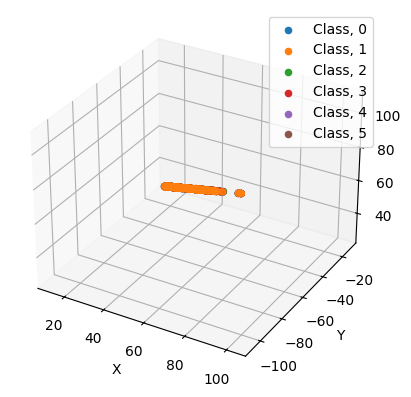

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Datos de ejemplo
X = S_emb_cat[:, 0]
Y = S_emb_cat[:, 1]
Z = S_emb_cat[:, 2]
# labels = np.array([0] * S1_emb.shape[0] + [1] * S2_emb.shape[0])  # labels

fig = plt.figure()
ax = fig.add_subplot(projection="3d")

# Separar clases
for label in np.unique(labels):
	ax.scatter(X[labels == label], Y[labels == label], Z[labels == label], label="Class, {}".format(label))

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.show()

##### Similarity analysis (Hungarian)

In [ ]:
print(D.shape)
D

Truth

In [ ]:
print(data)
print(test_pairs.shape)
print(test_pairs)

In [ ]:
if (data == "ACM_DBLP"):
	test_pairs_ = test_pairs
elif (data == "Douban Online_Offline"):
	test_pairs_ = test_pairs.T
	
truth = test_pairs_[test_pairs_[:, 1].argsort()]
print(truth.shape)
truth

In [ ]:
truth_ = test_pairs_[test_pairs_[:, 0].argsort()]
print(truth_.shape)
truth_

#### Option 0

In [ ]:
def hungarian(D):
	print("0")
	P = torch.zeros_like(D)
	matrix = D.tolist()
	m = Munkres()
	print("1")
	indexes = m.compute(matrix)
	print("2")
	total = 0
	for r, c in tqdm(indexes):
		print(r)
		P[r][c] = 1
		total += matrix[r][c]
	return P.t()

X = hungarian(D)
print(X.shape)
# online_offline: 215m
# acm_dblp: 2112m
X

In [ ]:
# save

X = X.cpu().numpy()
np.save("P_hungarian_ACM_DBLP", X)

In [ ]:
# load

X = np.load("P_hungarian.npy")
X

In [ ]:
option0 = []
m, n = X.shape
for i in range(m):
	for j in range(n):
		if X[i][j] == 1:
			option0.append([j, i]) # S, S_hat
option0 = np.array(option0)
print(len(option0))
option0

In [ ]:
matching = test_matching(truth, option0)
print(len(matching))
print(len(matching) / len(truth))
matching

#### Option 1

In [ ]:
total_cost, assignments = hungarian_algorithm(D.cpu())

In [ ]:
option1 = np.array(assignments)
option1 = option1[option1[:, 1].argsort()]
print(option1.shape)
option1

In [ ]:
option1_ = option1[:, [1, 0]]
option1_

In [ ]:
matching = test_match(truth, option1)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)

plot_match(G1, G2, matching)

#### Option 2

In [ ]:
import pygmtools as pygm

X = pygm.hungarian(D.cpu().numpy())
print(X.shape)
X

In [ ]:
option2 = matrix_to_edge(X)
option2

In [ ]:
option2_ = option2[:, [1, 0]]
option2_

In [ ]:
matching = test_match(truth, option2)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching)

#### Option 3

In [ ]:
indices = []
for i in range(D.shape[0]):
	dist_list = D[i]
	sorted_neighbors = torch.argsort(dist_list).cpu()
	indices.append([i, sorted_neighbors[0]])

option3 = np.array(indices)
option3 = option3[option3[:, 1].argsort()]
print(option3.shape)
option3

In [ ]:
option3_ = option3[:, [1, 0]]
option3_

In [ ]:
matching = test_match(truth, option3)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching)

#### Option 4

In [ ]:
X = greedy_match(D)
X = X.todense()
X = np.array(X)
print(X.shape)
print(X)

In [ ]:
option4 = matrix_to_edge(X)
option4

In [ ]:
option4_ = option4[:, [1, 0]]
option4_

In [ ]:
matching = test_match(truth, option4)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching)

#### Option 5

In [ ]:
D_ = complete_to_square(D.cpu(), pad_value=100.0)
print(D_.shape)
D_

In [ ]:
D.shape

In [ ]:
# X = get_match(torch.tensor(D_), device)
X = get_match(D, device)
print(X.shape)
X

In [ ]:
option5 = matrix_to_edge(X)
option5

In [ ]:
option5_ = option5[:, [1, 0]]
option5_

In [ ]:
matching = test_match(truth, option5_) # ACM_DBLP (option5_)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching)

---

In [ ]:
a = torch.tensor([[0.0,  0.0], [0.0, 1.0], [0.0,  2.0]])
print(a)
b = torch.tensor([[0.0, 1.0 ], [1.0,  1.0]])
print(b)
torch.cdist(a, b, p=2)

In [ ]:
a = torch.tensor([[4.01, 3.0, 2.0, 0.1, 4.0]])
print(a)
torch.argsort(a, dim=1)

In [ ]:
a = np.array([[9, 2, 3],
			  [4, 5, 6],
			  [7, 0, 5]])

a[a[:, 2].argsort()]